# Previous version


## Мобильное приложение
На мобильном устройстве пользователя в файл пишутся действия пользователя и системы в процессе взаимодействия с устройством.

Действия записываются без метки "полезная деятельность/бесполезная". Фильтр по типу деятельности приходится выполнять в ручном режиме - запускать службу и следить, чтобы во время её работы выполнялся только один тип деятельности.

Записываются не все параметры, которые собирает система, а только некоторые, предположительно информативные.

## Нейронная часть
Реализация отсутствует. Есть предположение по подходящим алгоритмам

# New Version


## Мобильное приложение
Действия размечаются по типу деятельности:
*   полезная деятельность
*   короткие видео
*   бесполезная(не только короткие видео)
*   неопределенное(если метку не проставил пользователь)

Улучшен интерфейс. Теперь можно более гибко управляться с записью своих действий в файл.

### Диалог с выбором типа деятельности



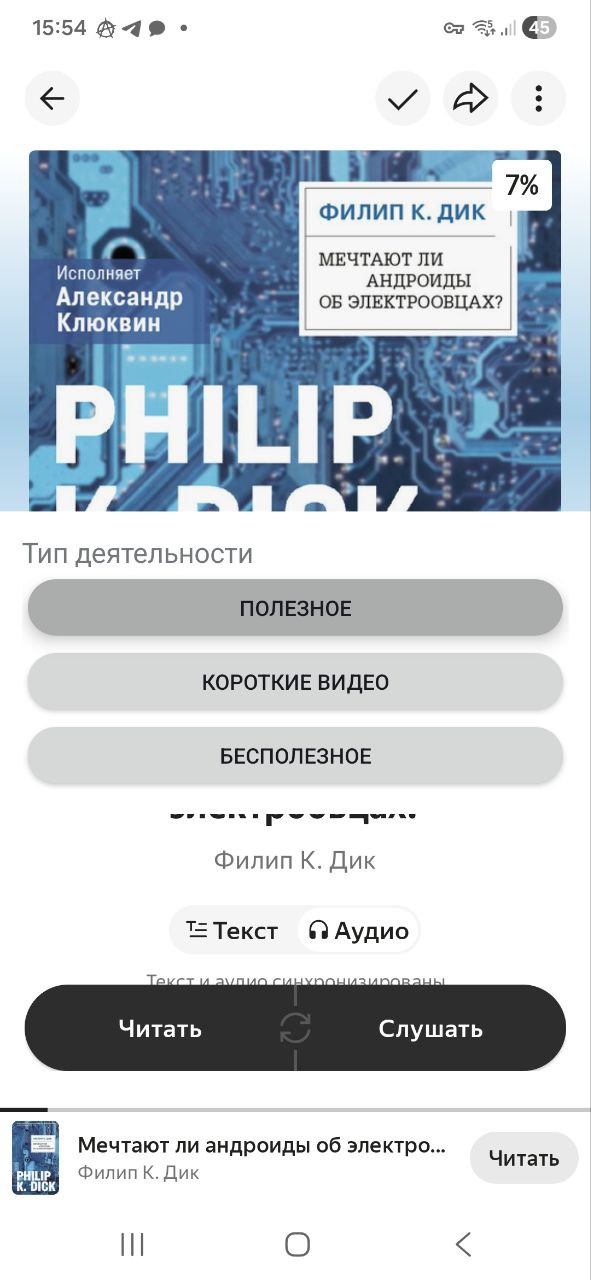

### Интерфейс приложения

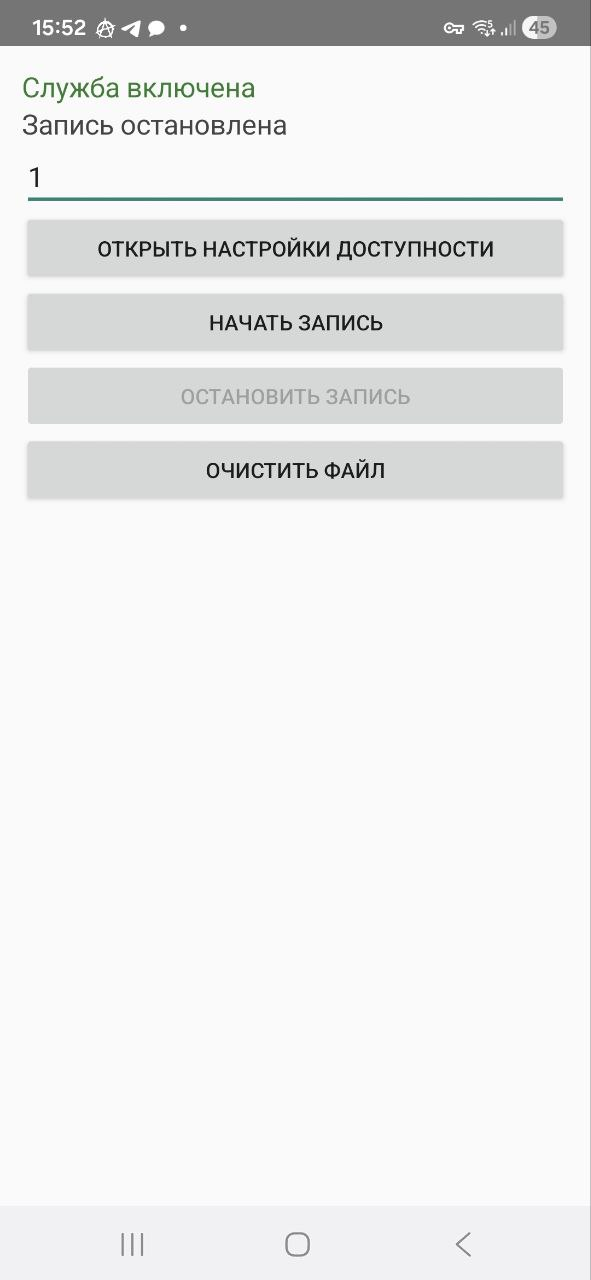

## Искуственно-интеллектуальная часть
Показана ниже

Предполагается, что на вход серверному приложению подаётся файл с действиями пользователя. На его основе выделятся признак, по которым можно охарактеризовать тип деятеьноти и по которым учится алгоритм.

Ниже показан процесс выделения этих признаком, их описание, характеризующие датасет графики и три попытки обучения разных моделей

In [1]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Диплом/data_1612.csv')

Mounted at /content/drive


In [2]:
df = data

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import gdown
from pathlib import Path

RAW_FILE = data
PROCESSED_FILE = "gesture_features.csv"

CHECK_INTERVAL_MIN = 2  # в минутах

In [4]:
df.head(5)

,sessionId,activityType,eventType,eventTime,package
0,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791741,2e429fcc-940c-4903-ae65-469e3793c933
1,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791747,2e429fcc-940c-4903-ae65-469e3793c933
2,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791782,2e429fcc-940c-4903-ae65-469e3793c933
3,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_STATE_CHANGED,96791782,2e429fcc-940c-4903-ae65-469e3793c933
4,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791858,2e429fcc-940c-4903-ae65-469e3793c933


In [5]:
df.tail(5)

,sessionId,activityType,eventType,eventTime,package
118400,570df380-6db0-4076-988e-b3423f05ebce,tiktok,TYPE_WINDOW_CONTENT_CHANGED,392059329,com.instagram.android
118401,570df380-6db0-4076-988e-b3423f05ebce,tiktok,TYPE_WINDOW_CONTENT_CHANGED,392059329,com.instagram.android
118402,570df380-6db0-4076-988e-b3423f05ebce,tiktok,TYPE_WINDOW_CONTENT_CHANGED,392059430,com.instagram.android
118403,570df380-6db0-4076-988e-b3423f05ebce,tiktok,TYPE_WINDOW_CONTENT_CHANGED,392059529,com.instagram.android
118404,570df380-6db0-4076-988e-b3423f05ebce,tiktok,TYPE_WINDOW_CONTENT_CHANGED,392059530,com.instagram.android


In [6]:
# eventTime в милисекундах
df["eventTime"] = pd.to_numeric(df["eventTime"], errors="coerce")
df = df.dropna(subset=["eventTime"])

# преобразование в datetime
# время будет в 1970, но дальше мы будем считать разницу между событиями, а время вроде не стало идти быстрее с 1970 года
df["timestamp"] = pd.to_datetime(df["eventTime"], unit="ms")

# преобразование в строки
df["eventType"] = df["eventType"].astype(str)
df["package"] = df["package"].astype(str)
df["activityType"] = df["activityType"].astype(str)

In [7]:
df.head(10)

,sessionId,activityType,eventType,eventTime,package,timestamp
0,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791741,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.741
1,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791747,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.747
2,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791782,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.782
3,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_STATE_CHANGED,96791782,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.782
4,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791858,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.858
5,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_ANNOUNCEMENT,96791901,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.901
6,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791944,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.944
7,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_STATE_CHANGED,96791944,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.944
8,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96792046,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:12.046
9,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96792153,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:12.153


Наши любимые окна
Нарезаем сессии на 2минутные отрезки

In [8]:
df["windowStart"] = df["timestamp"].dt.floor(f"{CHECK_INTERVAL_MIN}min")

Типы данных в наборе:

Удалим записи с типом unknown

In [9]:
#df["activityType"] = df["activityType"].replace("unknown", "good")
#types = df["activityType"].unique()
#types
df = df[~df['activityType'].isin(['unknown'])]
types = df["activityType"].unique()
types

array(['tiktok', 'doom', 'good'], dtype=object)

Сгруппируем по сессии, времени начала сессии и типа активности

In [10]:
grouped = df.groupby(["sessionId", "windowStart", "activityType"],dropna=False)


In [11]:
types = df["activityType"].unique()
types

array(['tiktok', 'doom', 'good'], dtype=object)

Для событий добавлено время начала сессии (windowStart)

In [12]:
sessions = df["sessionId"].unique()

s1, s2, s3 = sessions[:3]

sample_df = pd.concat([
    df[df["sessionId"] == s1].head(5),
    df[df["sessionId"] == s2].head(5),
    df[df["sessionId"] == s3].head(5)
])

sample_df

,sessionId,activityType,eventType,eventTime,package,timestamp,windowStart
0,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791741,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.741,1970-01-02 02:52:00
1,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791747,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.747,1970-01-02 02:52:00
2,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791782,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.782,1970-01-02 02:52:00
3,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_STATE_CHANGED,96791782,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.782,1970-01-02 02:52:00
4,2e429fcc-940c-4903-ae65-469e3793c933,tiktok,TYPE_WINDOW_CONTENT_CHANGED,96791858,2e429fcc-940c-4903-ae65-469e3793c933,1970-01-02 02:53:11.858,1970-01-02 02:52:00
61876,84f63478-01e8-4015-a5b0-7cd1ef6f2874,doom,TYPE_WINDOW_CONTENT_CHANGED,357020125,com.example.antitiktok,1970-01-05 03:10:20.125,1970-01-05 03:10:00
61877,84f63478-01e8-4015-a5b0-7cd1ef6f2874,doom,TYPE_WINDOW_CONTENT_CHANGED,357020126,com.example.antitiktok,1970-01-05 03:10:20.126,1970-01-05 03:10:00
61878,84f63478-01e8-4015-a5b0-7cd1ef6f2874,doom,TYPE_VIEW_CLICKED,357020126,com.example.antitiktok,1970-01-05 03:10:20.126,1970-01-05 03:10:00
61879,84f63478-01e8-4015-a5b0-7cd1ef6f2874,doom,TYPE_WINDOW_CONTENT_CHANGED,357021766,com.sec.android.app.launcher,1970-01-05 03:10:21.766,1970-01-05 03:10:00
61880,84f63478-01e8-4015-a5b0-7cd1ef6f2874,doom,TYPE_WINDOW_STATE_CHANGED,357021767,com.sec.android.app.launcher,1970-01-05 03:10:21.767,1970-01-05 03:10:00


In [13]:
features = grouped.apply(lambda g: pd.Series({

    # -------- базовые счётчики --------
    "event_count": len(g),

    "scroll_count": (g["eventType"] == "TYPE_VIEW_SCROLLED").sum(),
    "click_count": (g["eventType"] == "TYPE_VIEW_CLICKED").sum(),

    # -------- интенсивность --------
    "scrolls_per_minute":
        (g["eventType"] == "TYPE_VIEW_SCROLLED").sum() / CHECK_INTERVAL_MIN,

    # -------- приложения --------
    "unique_apps": g["package"].nunique(),

    "top_app_ratio":
        g["package"].value_counts(normalize=True).iloc[0]
        if len(g) > 0 else 0,

    # -------- темп событий --------
    "mean_inter_event_time_ms":
        g["timestamp"].diff().dt.total_seconds().mean() * 1000
        if len(g) > 1 else 0,

}))


/tmp/ipython-input-3468292954.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features = grouped.apply(lambda g: pd.Series({


In [14]:
features_df = features.reset_index()

# Убираем NaN / inf
features_df = (
    features_df
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)


In [15]:
features_df.head(5)


,sessionId,windowStart,activityType,event_count,scroll_count,click_count,scrolls_per_minute,unique_apps,top_app_ratio,mean_inter_event_time_ms
0,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:14:00,tiktok,158.0,0.0,0.0,0.0,1.0,1.000000,119.133758
1,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:16:00,tiktok,941.0,9.0,1.0,4.5,2.0,0.997875,127.584043
2,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:18:00,tiktok,1140.0,7.0,0.0,3.5,2.0,0.998246,105.213345
3,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:20:00,tiktok,1004.0,22.0,3.0,11.0,2.0,0.998008,119.543370
4,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:22:00,tiktok,1979.0,467.0,2.0,233.5,2.0,0.998989,60.597573


Переместим в конец столбец с целевой переменной

In [16]:
cols = [c for c in features_df.columns if c != "activityType"] + ["activityType"]
features_df = features_df[cols]
features_df.head(5)

,sessionId,windowStart,event_count,scroll_count,click_count,scrolls_per_minute,unique_apps,top_app_ratio,mean_inter_event_time_ms,activityType
0,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:14:00,158.0,0.0,0.0,0.0,1.0,1.000000,119.133758,tiktok
1,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:16:00,941.0,9.0,1.0,4.5,2.0,0.997875,127.584043,tiktok
2,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:18:00,1140.0,7.0,0.0,3.5,2.0,0.998246,105.213345,tiktok
3,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:20:00,1004.0,22.0,3.0,11.0,2.0,0.998008,119.543370,tiktok
4,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:22:00,1979.0,467.0,2.0,233.5,2.0,0.998989,60.597573,tiktok


In [17]:
features_df = features_df.loc[:, ~(features_df.fillna(0) == 0).all()]

##Признаки
**sessionId**	- GUID сессии. Используется для объединения событий в одну пользовательскую сессию

**windowStart**	- Начало сессии или окна

**activityType**	- Тип активности или приложения

**event_count**	- Общее количество событий, зафиксированных в рамках окна

**scroll_count** - Количество событий скролла в рамках окна

**click_count**	 - Количество кликов или взаимодействий с элементами интерфейса

**scrolls_per_minute**	- Среднее количество прокруток в минуту

**unique_apps**	- Количество уникальных приложений, зафиксированных в рамках окна

**top_app_ratio** -	Доля наиболее часто используемого приложения относительно всех событий в рамках окна

**mean_inter_event_time_ms** - Среднее время между последовательными событиями в миллисекундах

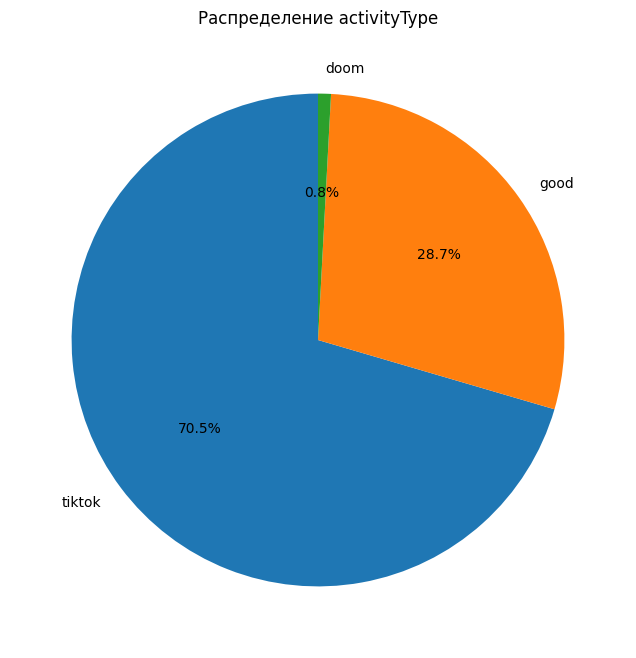

In [18]:
types_counts = features_df['activityType'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    types_counts.values,
    labels=types_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Распределение activityType')
plt.show()

Бесполезной деятельности, но не тиктоков слишком мало. Пока не будем учитывать и ее

In [19]:
features_df = features_df[~features_df['activityType'].isin(['doom'])]


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

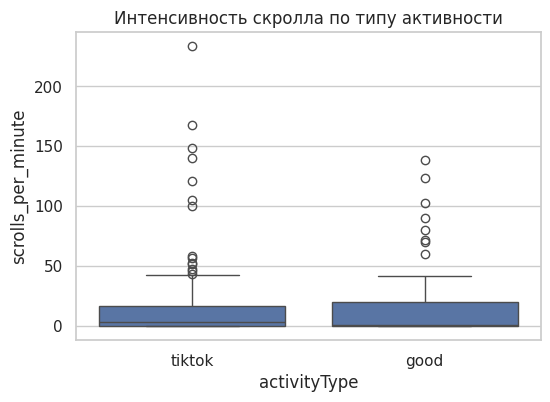

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=features_df,
    x="activityType",
    y="scrolls_per_minute"
)
plt.title("Интенсивность скролла по типу активности")
plt.show()


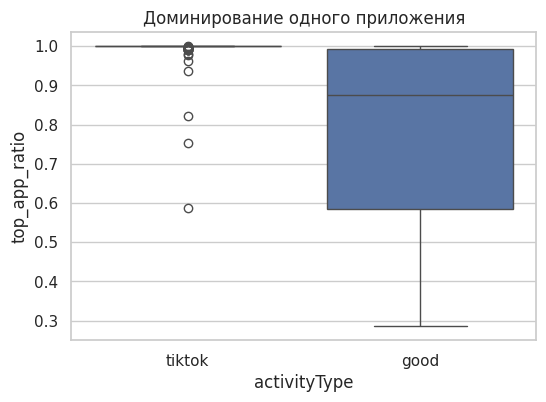

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=features_df,
    x="activityType",
    y="top_app_ratio"
)
plt.title("Доминирование одного приложения")
plt.show()


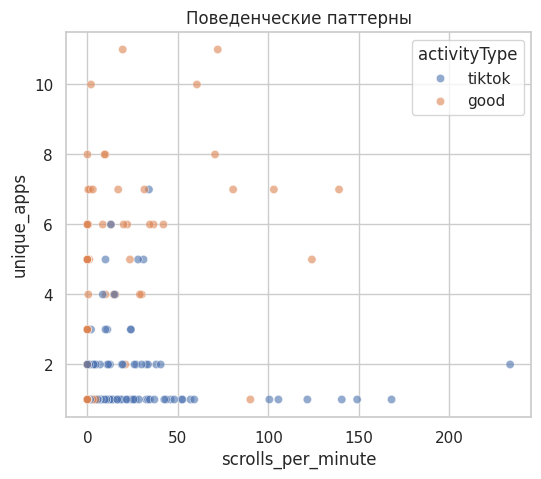

In [23]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=features_df,
    x="scrolls_per_minute",
    y="unique_apps",
    hue="activityType",
    alpha=0.6
)
plt.title("Поведенческие паттерны")
plt.show()


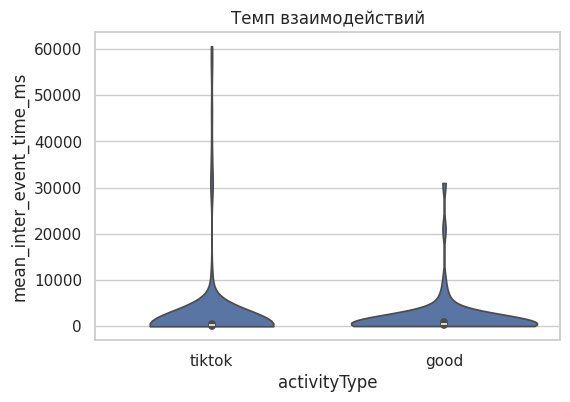

In [24]:
plt.figure(figsize=(6,4))
sns.violinplot(
    data=features_df,
    x="activityType",
    y="mean_inter_event_time_ms",
    cut=0
)
plt.title("Темп взаимодействий")
plt.show()


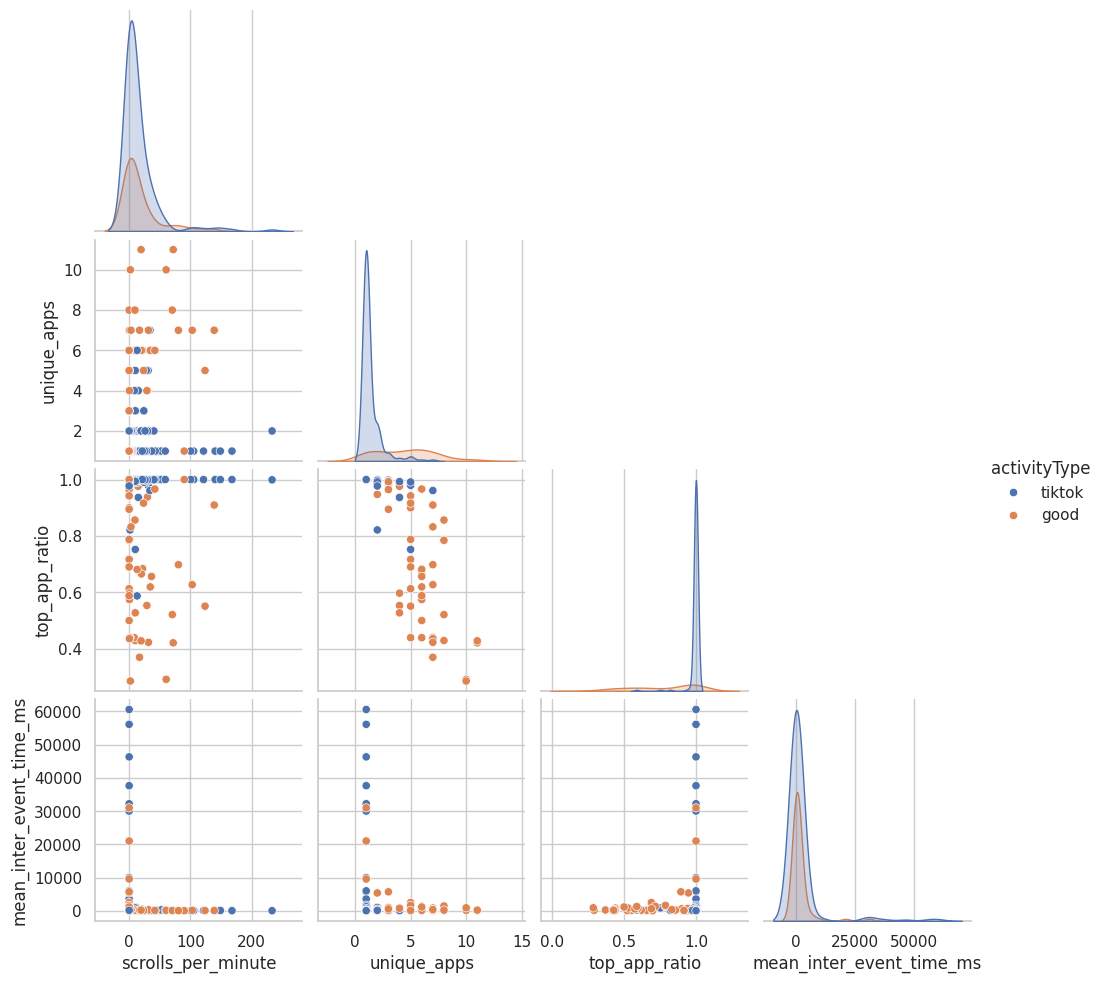

In [25]:
sns.pairplot(
    features_df,
    vars=[
        "scrolls_per_minute",
        "unique_apps",
        "top_app_ratio",
        "mean_inter_event_time_ms"
    ],
    hue="activityType",
    corner=True
)
plt.show()


### Интересные выводы по графикам
Классы не линейно разделимы, но заметны поведенческие паттерны.
Короткие видео отличаются высокой частотой прокруток, низким числом используемых приложений и преобаладанием одного приложения.
В то же время полезная активность характеризуется большей вариативностью приложений и большими интервалами между событиями.

## Подготовка данных

Добавим данных класса good, удалим малочисленные doom и unknown

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC

X = features_df.drop(columns=['activityType', 'sessionId', 'windowStart'])
y = features_df['activityType']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# кодирование категориального столбца
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

smote = SMOTE(
    sampling_strategy='not majority',
    random_state=42,
    k_neighbors=5
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train_enc)

In [27]:
X.head(5)

,event_count,scroll_count,click_count,scrolls_per_minute,unique_apps,top_app_ratio,mean_inter_event_time_ms
0,158.0,0.0,0.0,0.0,1.0,1.000000,119.133758
1,941.0,9.0,1.0,4.5,2.0,0.997875,127.584043
2,1140.0,7.0,0.0,3.5,2.0,0.998246,105.213345
3,1004.0,22.0,3.0,11.0,2.0,0.998008,119.543370
4,1979.0,467.0,2.0,233.5,2.0,0.998989,60.597573


In [28]:
dict(zip(le.classes_, le.transform(le.classes_)))

{'good': np.int64(0), 'tiktok': np.int64(1)}

0 - полезное
1 - тиктоки

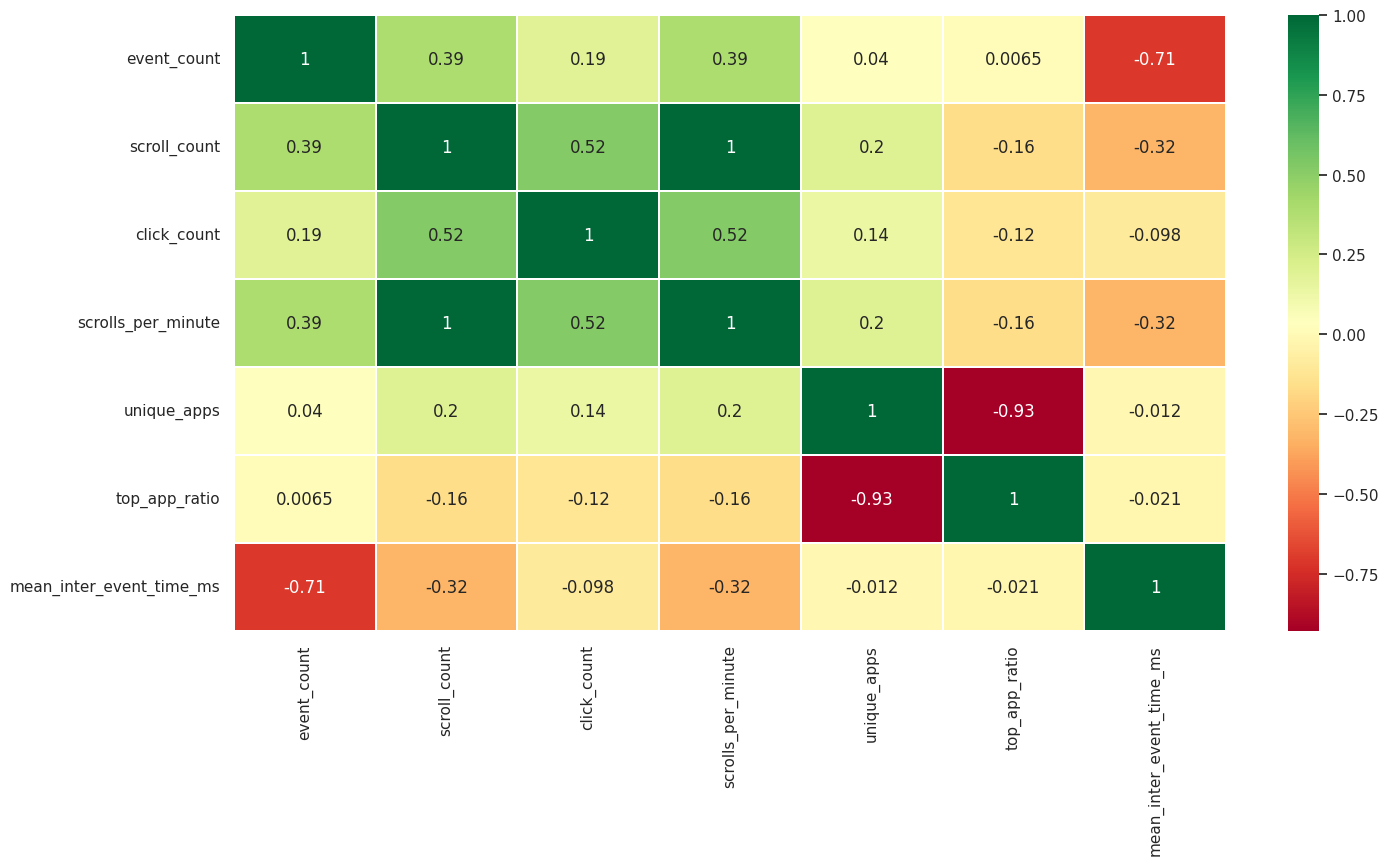

In [29]:
sns.heatmap(X.corr('kendall'),annot=True,cmap='RdYlGn',linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(16, 8)
plt.show()

Отрицательная корреляция между числом уникальных приложений и долей доминирующего приложения подтверждает гипотезу о различиях между полезной деятельностью и потреблением коротких видео.

## Обучение

### Попытка обучить случайный лес

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_res, y_train_res)

y_pred = rf.predict(X_test)

print(classification_report(
    y_test_enc,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

        good       0.71      0.88      0.79        17
      tiktok       0.95      0.86      0.90        42

    accuracy                           0.86        59
   macro avg       0.83      0.87      0.84        59
weighted avg       0.88      0.86      0.87        59



Тиктоки распознаются хорошо, полезное чуть похуже, в среднем неплохо 91% точности

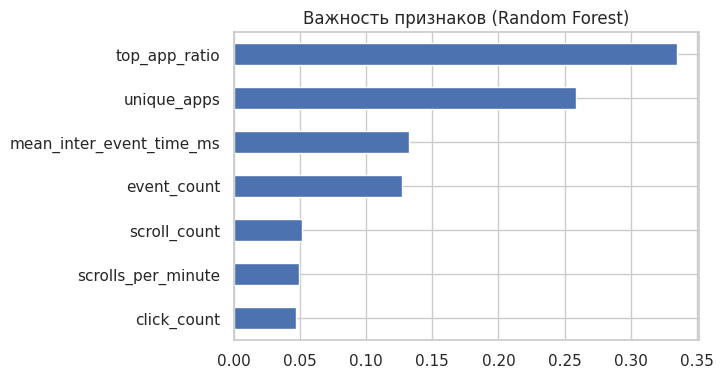

In [31]:
import pandas as pd

fi = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(6,4))
fi.plot(kind="barh")
plt.title("Важность признаков (Random Forest)")
plt.show()


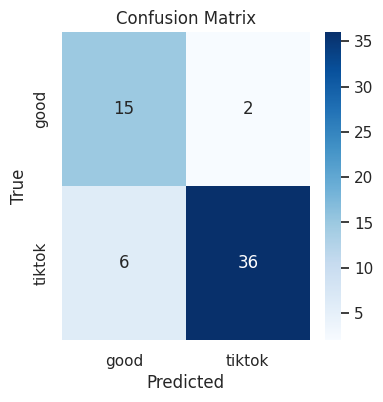

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_enc, y_pred, labels=[0,1])

plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


### Попытка обучить CatBoost

In [33]:
!pip install catboost


In [34]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

cb = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=False
)

cb.fit(
    X_train_res,
    y_train_res,
    eval_set=(X_test, y_test_enc)
)

y_pred_cb = cb.predict(X_test)

print(classification_report(
    y_test_enc,
    y_pred_cb,
    target_names=le.classes_
))


              precision    recall  f1-score   support

        good       0.79      0.88      0.83        17
      tiktok       0.95      0.90      0.93        42

    accuracy                           0.90        59
   macro avg       0.87      0.89      0.88        59
weighted avg       0.90      0.90      0.90        59



Результаты лучше, чем у случайного леса. Полезная деятельность распознается лучше, на тиктоках меньше ошибок => общая точность тоже повыше




### Попытка обучить XBoost

In [35]:
!pip install xgboost


In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(
    y_test_enc,
    y_pred_xgb,
    target_names=le.classes_
))


=== XGBoost ===
              precision    recall  f1-score   support

        good       0.72      0.76      0.74        17
      tiktok       0.90      0.88      0.89        42

    accuracy                           0.85        59
   macro avg       0.81      0.82      0.82        59
weighted avg       0.85      0.85      0.85        59



Результаты лучше совпадают со случайным лесом. Так даже неинтересно


## Выводы

Все методы, определенные в рамках второго НИРа хорошо подходят для решения задачи классификации типа деятельности по действиям пользователя

Нужно смотреть больше коротких видео и чаще пользоваться телефоном в целом. Собрать ещё побольше и поаккуратнее датасет и попробовать дообучить модели

Остаётся всего-то перенести это дело в полноценное серверное приложение, прикрутить апишку и наладить обработку файлов в промышленном масштабе.

# Точно нейронная часть

## Подготовка данных

In [37]:
features_df.head()

,sessionId,windowStart,event_count,scroll_count,click_count,scrolls_per_minute,unique_apps,top_app_ratio,mean_inter_event_time_ms,activityType
0,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:14:00,158.0,0.0,0.0,0.0,1.0,1.000000,119.133758,tiktok
1,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:16:00,941.0,9.0,1.0,4.5,2.0,0.997875,127.584043,tiktok
2,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:18:00,1140.0,7.0,0.0,3.5,2.0,0.998246,105.213345,tiktok
3,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:20:00,1004.0,22.0,3.0,11.0,2.0,0.998008,119.543370,tiktok
4,0c935730-f4fa-48ee-889b-df26621b8e96,1970-01-05 03:22:00,1979.0,467.0,2.0,233.5,2.0,0.998989,60.597573,tiktok


In [38]:
from sklearn.preprocessing import StandardScaler

X = features_df.drop(columns=["activityType", "sessionId", "windowStart"])
y = features_df["activityType"]

# label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

# split по sessionId (как у тебя уже было)
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.25, random_state=42)
train_idx, test_idx = next(
    gss.split(X, y_enc, groups=features_df["sessionId"])
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_enc[train_idx], y_enc[test_idx]

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Модель 1

In [39]:
!pip install tensorflow

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


Модель состоит из двух слоев и предтавляет собой полносвязную нейросеть. Функция активации - ReLU. Первый слой - 30 нейрончиков, второй - 15. На выходе сигмоида

In [72]:
model = Sequential([
    Dense(30, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(15, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [73]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.4967 - auc: 0.5848 - loss: 0.6571 - val_accuracy: 0.8537 - val_auc: 0.6024 - val_loss: 0.5745
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6788 - auc: 0.4949 - loss: 0.6370 - val_accuracy: 0.8780 - val_auc: 0.7262 - val_loss: 0.5411
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7428 - auc: 0.4101 - loss: 0.6091 - val_accuracy: 0.8780 - val_auc: 0.7524 - val_loss: 0.5129
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7934 - auc: 0.5467 - loss: 0.5739 - val_accuracy: 0.9024 - val_auc: 0.7881 - val_loss: 0.4890
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8466 - auc: 0.7725 - loss: 0.4963 - val_accuracy: 0.9024 - val_auc: 0.8357 - val_loss: 0.4644
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7979 - auc: 0.7590 - loss: 0.5068 - val_accuracy: 0.8780 - val_auc: 0.8786 - val_loss: 0.4427
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 

In [93]:
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
              precision    recall  f1-score   support

        good       1.00      0.77      0.87        30
      tiktok       0.36      1.00      0.53         4

    accuracy                           0.79        34
   macro avg       0.68      0.88      0.70        34
weighted avg       0.93      0.79      0.83        34



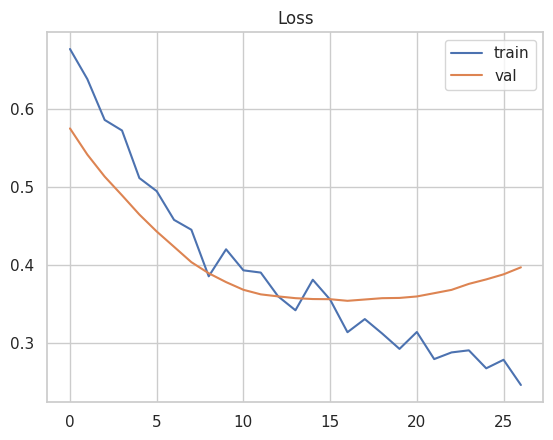

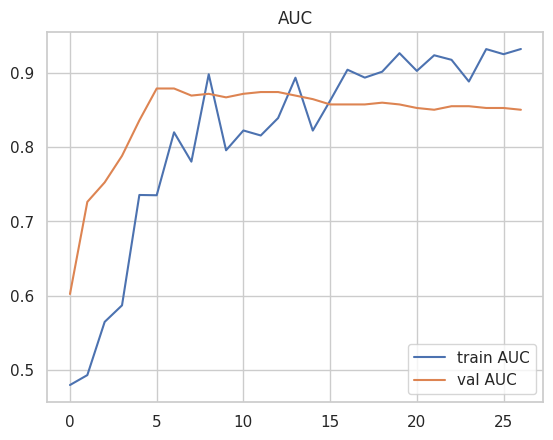

In [75]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()
plt.show()

plt.plot(history.history["auc"], label="train AUC")
plt.plot(history.history["val_auc"], label="val AUC")
plt.title("AUC")
plt.legend()
plt.show()


### Выводы

Итоговая точность в 79% впечатляет не так сильно, как результаты методов машинного обучения, но не расстраивает.

В процессе обучения заметно, что на ранних эпохах происходит быстрое увеличение качества как на обучающей, так и на тестовой выборке. Минимальное значение функции потерь наблюдается на 12–15 эпохах, после чего начинается незначительное переобучение. Максимальное значение AUC на тестовой выборке достигается на 8–10 эпохах, после чего начинается незначительное переобучение модели.

Стратегия ранней остановки поможет это невелировать и сохранить модель с наилучшей обобщающей способностью, а не последнюю версию



## Модель 2

Улучшенная версия первой модели. После каждого слоя добавлена BatchNormalization, нейрончиков на 1 больше на каждом слое.

In [78]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

In [79]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights_array))

print("Class weights:", class_weights)

Class weights: {0: np.float64(2.6447368421052633), 1: np.float64(0.6165644171779141)}


In [100]:
n_features = X_train_scaled.shape[1]

model2 = Sequential([
    Dense(32, activation="relu", input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [101]:
model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [102]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [103]:
history = model2.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.4250 - auc: 0.4423 - loss: 0.9345 - val_accuracy: 0.3659 - val_auc: 0.5048 - val_loss: 0.7939
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4727 - auc: 0.4873 - loss: 0.9280 - val_accuracy: 0.3415 - val_auc: 0.5881 - val_loss: 0.7773
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5605 - auc: 0.6263 - loss: 0.8143 - val_accuracy: 0.3659 - val_auc: 0.6548 - val_loss: 0.7577
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6578 - auc: 0.7912 - loss: 0.5498 - val_accuracy: 0.4146 - val_auc: 0.6667 - val_loss: 0.7395
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6316 - auc: 0.7916 - loss: 0.5908 - val_accuracy: 0.4634 - val_auc: 0.6786 - val_loss: 0.7249
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5857 - auc: 0.6855 - loss: 0.6347 - val_accuracy: 0.5610 - val_auc: 0.6881 - val_loss: 0.7163
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0

In [104]:
y_pred_prob = model2.predict(X_test_scaled).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        30
           1       0.40      1.00      0.57         4

    accuracy                           0.82        34
   macro avg       0.70      0.90      0.73        34
weighted avg       0.93      0.82      0.85        34



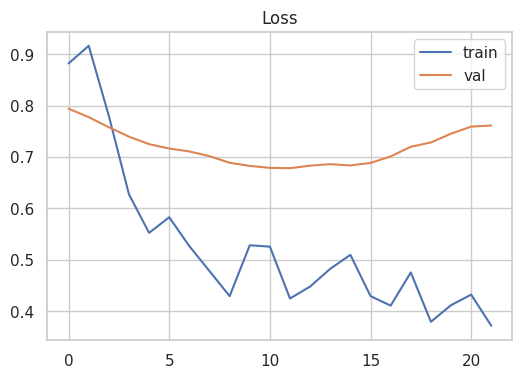

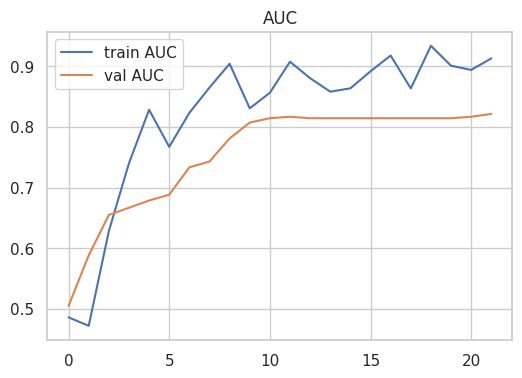

In [105]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()
plt.show()

# AUC
plt.figure(figsize=(6,4))
plt.plot(history.history["auc"], label="train AUC")
plt.plot(history.history["val_auc"], label="val AUC")
plt.title("AUC")
plt.legend()
plt.show()


### Выводы

Итоговая точность увеличилась до 82%, что ближе к результатам методов машинного обучения.

Модель достигает оптимального качества на валидационной выборке примерно на 9–11 эпохах, после чего начинается переобучение.

# Выводы по нейронкам

Данные имеют табличную структуру и представлены агрегированными признаками. Нейронные сети на них справились в среднем хуже, чем классические методы машинного обучения (худший результат методов МО - XGBoost 85%, лучший результат нерйонки - 82%).
Нейронные сети рассмотрены с целью сравнения, однако уступают бустингу по качеству.

В дальнейшем имеет смысл сравнить результаты обоих подходов на более абширном датасете.